✅ Total Samples: 2616
📉 RSSI Range: -35 to -29
📊 Avg RSSI: -31.933103975535168


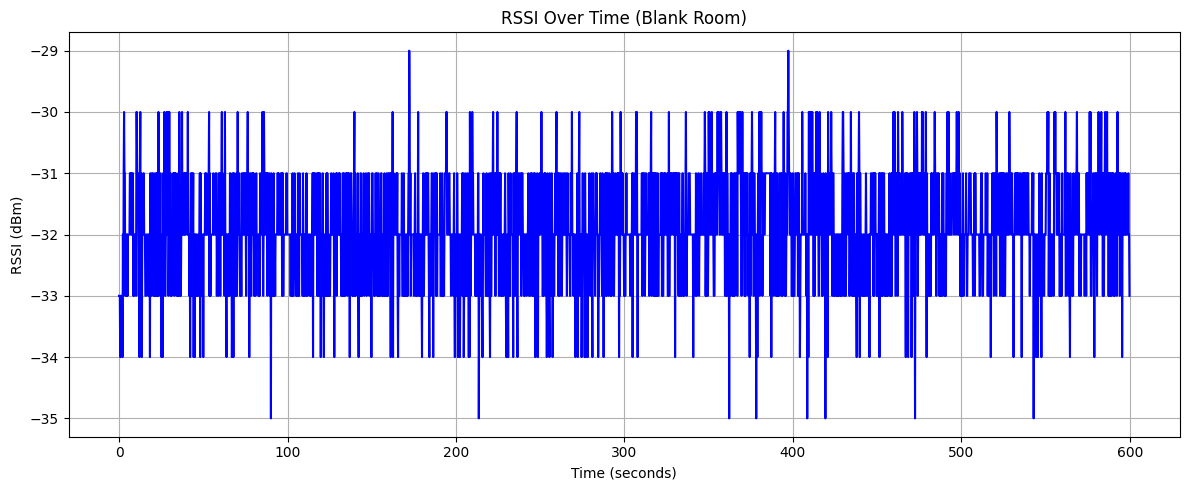

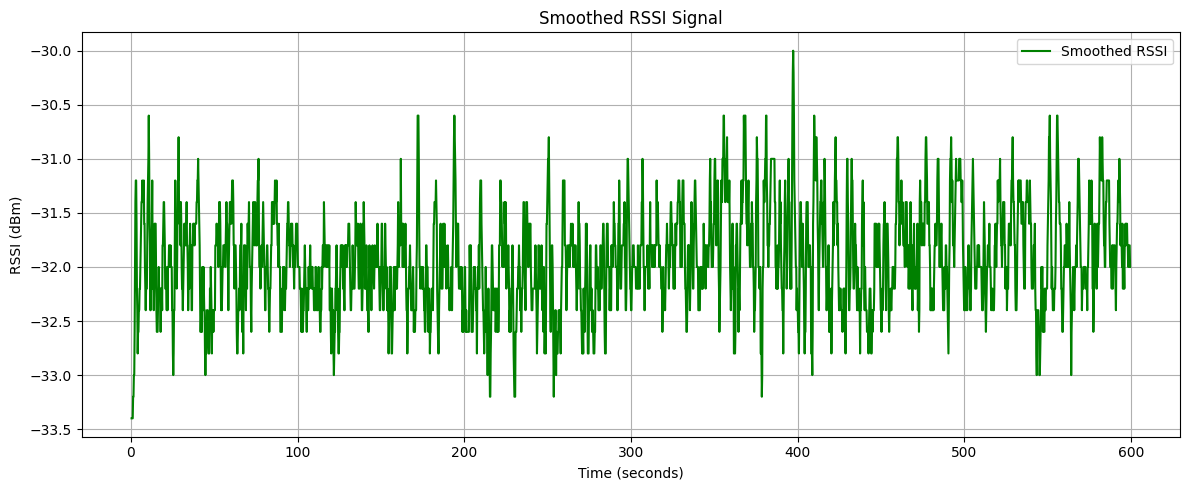

💾 Cleaned data saved as 'clean_blankroom.csv'


In [1]:
# blankroom.ipynb

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load CSV
df = pd.read_csv("blankroom.csv")
df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000  # Convert to seconds

# Step 3: Basic info
print("✅ Total Samples:", len(df))
print("📉 RSSI Range:", df['rssi'].min(), "to", df['rssi'].max())
print("📊 Avg RSSI:", df['rssi'].mean())

# Step 4: Plot RSSI over time
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="time_s", y="rssi", color='blue')
plt.title("RSSI Over Time (Blank Room)")
plt.xlabel("Time (seconds)")
plt.ylabel("RSSI (dBm)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: Optional - Smooth/clean data
df['rssi_avg'] = df['rssi'].rolling(window=5, center=True).mean()

# Step 6: Plot smoothed RSSI
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="time_s", y="rssi_avg", color='green', label="Smoothed RSSI")
plt.title("Smoothed RSSI Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("RSSI (dBm)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Save cleaned version
df[['time_s', 'rssi_avg']].dropna().to_csv("clean_blankroom.csv", index=False)
print("💾 Cleaned data saved as 'clean_blankroom.csv'")


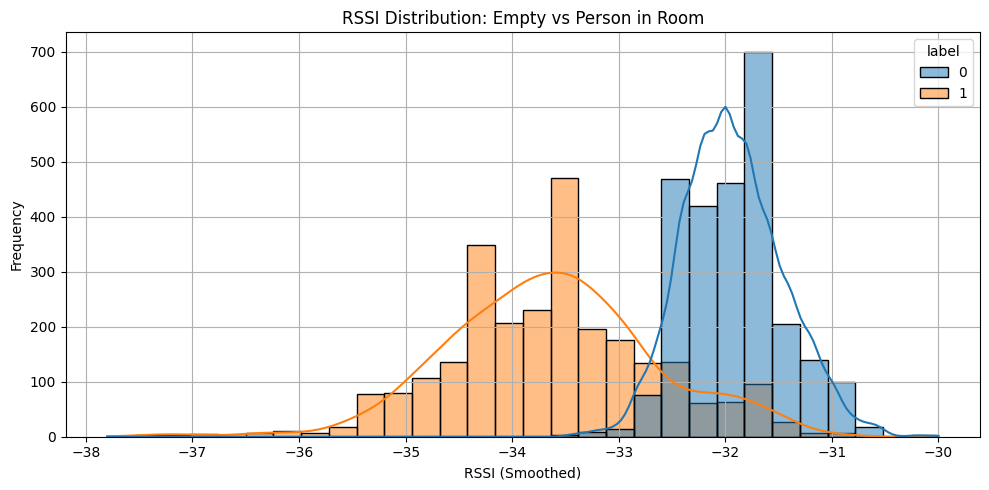

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df_blank = pd.read_csv("blankroom.csv")
df_blank["label"] = 0

df_person = pd.read_csv("personinroom.csv")
df_person["label"] = 1

# Combine
df_all = pd.concat([df_blank, df_person], ignore_index=True)

# Preprocessing
df_all["time_s"] = (df_all["timestamp_ms"] - df_all["timestamp_ms"].min()) / 1000
df_all["rssi_avg"] = df_all["rssi"].rolling(window=5, center=True).mean()

# Drop NaNs after smoothing
df_all = df_all.dropna()

# Plot RSSI by label
plt.figure(figsize=(10,5))
sns.histplot(data=df_all, x="rssi_avg", hue="label", bins=30, kde=True)
plt.title("RSSI Distribution: Empty vs Person in Room")
plt.xlabel("RSSI (Smoothed)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features and labels
X = df_all[["rssi_avg"]]
y = df_all["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9005736137667304
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       525
           1       0.92      0.88      0.90       521

    accuracy                           0.90      1046
   macro avg       0.90      0.90      0.90      1046
weighted avg       0.90      0.90      0.90      1046



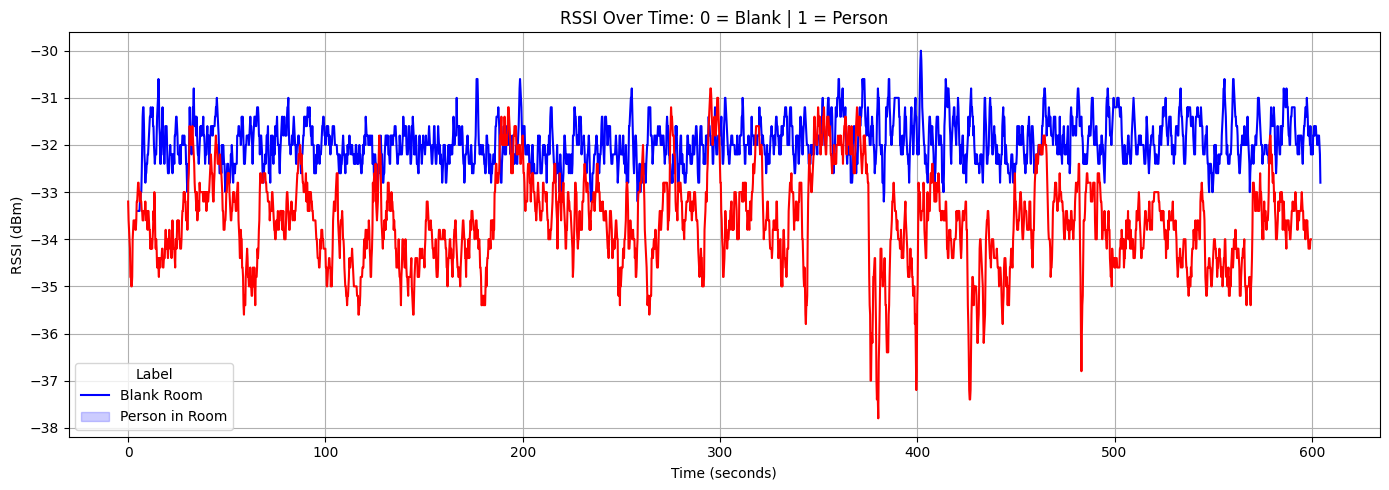

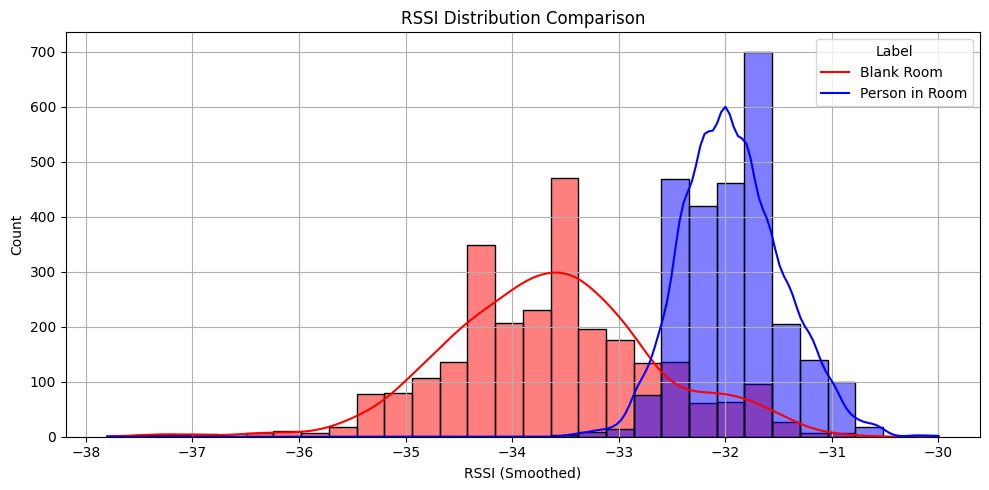

📊 RSSI Summary Stats:

                 min   max       mean       std
Blank Room     -33.4 -30.0 -31.932364  0.467858
Person in Room -37.8 -30.8 -33.631663  0.975385


In [4]:
# Step 1: Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load files
blank = pd.read_csv("blankroom.csv")
person = pd.read_csv("personinroom.csv")

blank["label"] = 0
person["label"] = 1

# Step 3: Merge both
df = pd.concat([blank, person], ignore_index=True)

# Step 4: Normalize time & Smooth RSSI
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000
df["rssi_avg"] = df["rssi"].rolling(window=5, center=True).mean()
df = df.dropna()

# Step 5: Plot RSSI over time
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x="time_s", y="rssi_avg", hue="label", palette=["blue", "red"])
plt.title("RSSI Over Time: 0 = Blank | 1 = Person")
plt.xlabel("Time (seconds)")
plt.ylabel("RSSI (dBm)")
plt.legend(title="Label", labels=["Blank Room", "Person in Room"])
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: Plot Distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="rssi_avg", hue="label", bins=30, kde=True, palette=["blue", "red"])
plt.title("RSSI Distribution Comparison")
plt.xlabel("RSSI (Smoothed)")
plt.ylabel("Count")
plt.legend(title="Label", labels=["Blank Room", "Person in Room"])
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Print Stats
grouped = df.groupby("label")["rssi_avg"].agg(["min", "max", "mean", "std"])
grouped.index = ["Blank Room", "Person in Room"]
print("📊 RSSI Summary Stats:\n")
print(grouped)


/tmp/ipykernel_685157/2097943429.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/max/mlenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


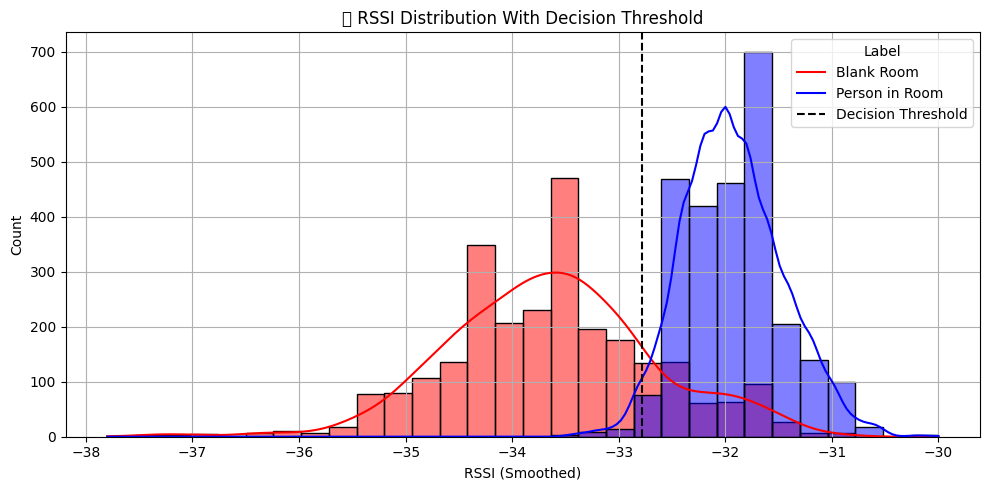

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="rssi_avg", hue="label", bins=30, kde=True, palette=["blue", "red"])
plt.axvline(x=-32.78, color='black', linestyle='--', label='Threshold = -32.78 dBm')
plt.title("📊 RSSI Distribution With Decision Threshold")
plt.xlabel("RSSI (Smoothed)")
plt.ylabel("Count")
plt.legend(title="Label", labels=["Blank Room", "Person in Room", "Decision Threshold"])
plt.grid(True)
plt.tight_layout()
plt.show()
